In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

In [4]:
df = pd.read_csv("../data/arabic_names.csv")

print(df.shape)
print(df.head(10))

(1196, 4)
  english_name arabic_name gender  \
0         Aali        عالي      m   
1      Aaliyah       عالية      f   
2       Aamina        آمنة      f   
3      Aaminah        آمنة      f   
4       'Aamir        عامر      m   
5      Aamir 1        عامر      m   
6      Aamir 2         آمر      m   
7       'Abbas       عبّاس      m   
8        Abbas       عبّاس      m   
9  Abd al-Aziz  عبد العزيز      m   

                                              origin  
0                                             Arabic  
1  Arabic, English (Modern), African American (Mo...  
2                    Arabic, Eastern African, Somali  
3                                             Arabic  
4                                             Arabic  
5                                       Arabic, Urdu  
6                                             Arabic  
7                                    Arabic, Persian  
8                              Arabic, Persian, Urdu  
9                               

In [5]:
# We only need arabic name the third column 
names = df['arabic_name'].tolist()

print(f"Total names: {len(names)}")
print(f"First 10: {names[:10]}")

Total names: 1196
First 10: ['عالي', 'عالية', 'آمنة', 'آمنة', 'عامر', 'عامر', 'آمر', 'عبّاس', 'عبّاس', 'عبد العزيز']


In [6]:
print(f"Unique names: {len(set(names))}")

# check lengths
lengths = [len(name) for name in names]
print(f"Shortest name: {min(lengths)} chars")
print(f"Longest name: {max(lengths)} chars")
print(f"Average length: {sum(lengths)/len(lengths):.1f} chars")

# how many names have a space?
multi_word = [n for n in names if ' ' in n]
print(f"\nMulti-word names: {len(multi_word)}")
print(f"Examples: {multi_word[:5]}")

Unique names: 205
Shortest name: 3 chars
Longest name: 13 chars
Average length: 5.5 chars

Multi-word names: 240
Examples: ['عبد العزيز', 'عبد الحميد', 'عبد القادر', 'عبد الكريم', 'عبد الله']


In [7]:
# Remove duplicates names 
names = list(sorted(set(names)))
print(names[:5])
print(len(names)) # check lenght 

['آدم', 'آسيا, آسية', 'آمر', 'آمنة', 'آمنة, أمينة']
205


In [8]:
# remove spaces 
names = [name.strip() for name in names]
print(names[:11])


['آدم', 'آسيا, آسية', 'آمر', 'آمنة', 'آمنة, أمينة', 'آية', 'أبرار', 'أبو', 'أبو الفضل', 'أبو بكر', 'أحمد']


In [9]:
# Remove , 

clean_names = []
for name in names:
    parts = name.split(',')
    parts = [part.strip() for part in parts]
    clean_names.extend(parts)

print(clean_names[:10])
print(len(clean_names))

['آدم', 'آسيا', 'آسية', 'آمر', 'آمنة', 'آمنة', 'أمينة', 'آية', 'أبرار', 'أبو']
211


In [10]:
# Now let's remove duplicate again 

new_names = list(sorted(set(clean_names)))
print(new_names[:5])
print(len(new_names))

['آدم', 'آسيا', 'آسية', 'آمر', 'آمنة']
207


In [11]:
# we need to remove these 'ِ', 'ّ', 'ٰ'

clean_names = []
for name in new_names:
    name = name.replace('ِ', '').replace('ّ', '').replace('ٰ', '')
    clean_names.append(name)

print(clean_names[:10])
print(len(clean_names))

['آدم', 'آسيا', 'آسية', 'آمر', 'آمنة', 'آية', 'أبرار', 'أبو', 'أبو الفضل', 'أبو بكر']
207


In [12]:
# rebuild the characters set from clean_names

chars = set()
for name in clean_names:
    for ch in name:
        chars.add(ch)

print(sorted(chars))
print(len(chars))

[' ', 'ء', 'آ', 'أ', 'ؤ', 'إ', 'ئ', 'ا', 'ب', 'ة', 'ت', 'ث', 'ج', 'ح', 'خ', 'د', 'ذ', 'ر', 'ز', 'س', 'ش', 'ص', 'ض', 'ط', 'ع', 'غ', 'ف', 'ق', 'ك', 'ل', 'م', 'ن', 'ه', 'و', 'ى', 'ي']
36


In [13]:
stoi = {'.': 0}
itos = {0 : '.'}
for i, ch in enumerate(sorted(chars), start=1):
    stoi[ch] = i
    itos[i] = ch
print(stoi)
print(itos)

{'.': 0, ' ': 1, 'ء': 2, 'آ': 3, 'أ': 4, 'ؤ': 5, 'إ': 6, 'ئ': 7, 'ا': 8, 'ب': 9, 'ة': 10, 'ت': 11, 'ث': 12, 'ج': 13, 'ح': 14, 'خ': 15, 'د': 16, 'ذ': 17, 'ر': 18, 'ز': 19, 'س': 20, 'ش': 21, 'ص': 22, 'ض': 23, 'ط': 24, 'ع': 25, 'غ': 26, 'ف': 27, 'ق': 28, 'ك': 29, 'ل': 30, 'م': 31, 'ن': 32, 'ه': 33, 'و': 34, 'ى': 35, 'ي': 36}
{0: '.', 1: ' ', 2: 'ء', 3: 'آ', 4: 'أ', 5: 'ؤ', 6: 'إ', 7: 'ئ', 8: 'ا', 9: 'ب', 10: 'ة', 11: 'ت', 12: 'ث', 13: 'ج', 14: 'ح', 15: 'خ', 16: 'د', 17: 'ذ', 18: 'ر', 19: 'ز', 20: 'س', 21: 'ش', 22: 'ص', 23: 'ض', 24: 'ط', 25: 'ع', 26: 'غ', 27: 'ف', 28: 'ق', 29: 'ك', 30: 'ل', 31: 'م', 32: 'ن', 33: 'ه', 34: 'و', 35: 'ى', 36: 'ي'}


In [14]:
# Or you can do this one stoi.items() gives you bothe the key and the value 
itos = {i: ch for ch, i in stoi.items()}
print(itos)

{0: '.', 1: ' ', 2: 'ء', 3: 'آ', 4: 'أ', 5: 'ؤ', 6: 'إ', 7: 'ئ', 8: 'ا', 9: 'ب', 10: 'ة', 11: 'ت', 12: 'ث', 13: 'ج', 14: 'ح', 15: 'خ', 16: 'د', 17: 'ذ', 18: 'ر', 19: 'ز', 20: 'س', 21: 'ش', 22: 'ص', 23: 'ض', 24: 'ط', 25: 'ع', 26: 'غ', 27: 'ف', 28: 'ق', 29: 'ك', 30: 'ل', 31: 'م', 32: 'ن', 33: 'ه', 34: 'و', 35: 'ى', 36: 'ي'}


In [15]:
# Building our trianing dataset 

block_size = 3

X, y = [], []

for name in clean_names:
    #print(name)
    context = [0] * block_size   # context =[0,0,0]
    for ch in name + '.':
        ix = stoi[ch]
        X.append(context)
        y.append(ix)
        #print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix]

X = torch.tensor(X)
y = torch.tensor(y)

In [16]:
# check the result 
# print(X.shape)
# print(y.shape)

# print(X[:5])
# print(y[:5])

In [17]:
# Implementing the Emdedding Table 

# Vocabulary size
vocab_size = len(stoi)

# Size of each character vector
embedding_dim = 10

# Create embedding table
# Each character gets a learnable vector of size 10
C = torch.randn((vocab_size, embedding_dim))

print("Embedding table shape:", C.shape)


# Embedding lookup
# Replace character IDs in X with their vectors
emb = C[X]

print("After embedding:", emb.shape)


# Flatten embeddings
# (batch_size, block_size, embedding_dim)
#        (1203, 3, 10)
#
# becomes:
#        (1203, 30)

emb = emb.view(emb.shape[0], -1)

print("After flatten:", emb.shape)

Embedding table shape: torch.Size([37, 10])
After embedding: torch.Size([1203, 3, 10])
After flatten: torch.Size([1203, 30])


In [18]:
# Build the MLP Forward Pass

# Initialize parameters

torch.manual_seed(42)

n_hidden = 100

# before : W1 = torch.randn((30, n_hidden))
W1 = torch.randn((30, n_hidden)) * 0.1 # W1: (30,100)
b1 = torch.zeros(n_hidden)  # b1: (100)

# before : W2 = torch.randn((n_hidden, vocab_size))
W2 = torch.randn((n_hidden, vocab_size)) * 0.1 # W2: (100,37)
b2 = torch.zeros(vocab_size) # W2: (100,37)



In [19]:
# Forward pass 

# Hidden layer
h = emb @ W1 + b1  # shape = (1203,100)

# Activation
h = torch.tanh(h)

# Output logits 
logits = h @ W2 + b2  # shape = (1203,37)

print("Hidden shape:", h.shape)
print("Logits shape:", logits.shape)

Hidden shape: torch.Size([1203, 100])
Logits shape: torch.Size([1203, 37])


In [20]:
# Calculate Loss
# the loss is calculated using −log(1/37) which is = 3.61 so we need to find a number closes to it 

loss = F.cross_entropy(logits, y)

print(loss.item()) # 19.4124755859375 to big in the first try so you need to edit W1 b1 and W2 b2 
print(logits.mean())
print(logits.std())
print(logits.max())
print(logits.min())

3.7286813259124756
tensor(0.0101)
tensor(0.4620)
tensor(1.6975)
tensor(-1.7362)


In [21]:
# Forward again

h = emb @ W1 + b1
h = torch.tanh(h)
logits = h @ W2 + b2

print("logits:")
print("mean:", logits.mean().item())
print("std:", logits.std().item())
print("max:", logits.max().item())
print("min:", logits.min().item())

loss = F.cross_entropy(logits, y)

print("loss:", loss.item())

logits:
mean: 0.010088328272104263
std: 0.46200311183929443
max: 1.6975356340408325
min: -1.7362076044082642
loss: 3.7286813259124756


In [22]:
# Train/Val/Test splits (80/10/10)

import random
random.seed(42)

random.shuffle(clean_names)

n1 = int(0.8 * len(clean_names))
n2 = int(0.9 * len(clean_names))

def build_dataset(names_list):
    X, y = [], []
    for name in names_list:
        context = [0] * block_size
        for ch in name + '.':
            ix = stoi[ch]
            X.append(context)
            y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(y)

Xtr, Ytr   = build_dataset(clean_names[:n1])
Xdev, Ydev = build_dataset(clean_names[n1:n2])
Xte, Yte   = build_dataset(clean_names[n2:])

print(f"Train:      {Xtr.shape[0]} examples")
print(f"Validation: {Xdev.shape[0]} examples")
print(f"Test:       {Xte.shape[0]} examples")

Train:      958 examples
Validation: 125 examples
Test:       120 examples


In [23]:
# Re-initialize all parameters cleanly with requires_grad=True

torch.manual_seed(42)

vocab_size    = len(stoi)   # 37
embedding_dim = 10
n_hidden      = 100

C  = torch.randn((vocab_size, embedding_dim))
W1 = torch.randn((block_size * embedding_dim, n_hidden)) * 0.1
b1 = torch.zeros(n_hidden)
W2 = torch.randn((n_hidden, vocab_size)) * 0.01
b2 = torch.zeros(vocab_size)

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

total = sum(p.nelement() for p in parameters)
print(f"Total parameters: {total}")

Total parameters: 7207


In [24]:
# Training loop

train_losses = []
val_losses   = []

max_steps  = 30000
batch_size = 32

# Learning rate schedule: start high, decay after halfway
def get_lr(step):
    return 0.1 if step < max_steps // 2 else 0.01

for step in range(max_steps):

    # Mini-batch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))

    # Forward pass
    emb    = C[Xtr[ix]]                         # (B, block_size, emb_dim)
    emb_flat = emb.view(emb.shape[0], -1)       # (B, 30)
    h      = torch.tanh(emb_flat @ W1 + b1)     # (B, n_hidden)
    logits = h @ W2 + b2                         # (B, vocab_size)
    loss   = F.cross_entropy(logits, Ytr[ix])

    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update
    lr = get_lr(step)
    for p in parameters:
        p.data += -lr * p.grad

    # Logging
    if step % 3000 == 0:
        # Validation loss (no grad needed)
        with torch.no_grad():
            emb_v  = C[Xdev].view(Xdev.shape[0], -1)
            h_v    = torch.tanh(emb_v @ W1 + b1)
            logits_v = h_v @ W2 + b2
            val_loss = F.cross_entropy(logits_v, Ydev).item()

        train_losses.append(loss.item())
        val_losses.append(val_loss)
        print(f"Step {step:6d} | train loss: {loss.item():.4f} | val loss: {val_loss:.4f} | lr: {lr}")

print("\nDone training!")

Step      0 | train loss: 3.6170 | val loss: 3.5942 | lr: 0.1
Step   3000 | train loss: 0.7629 | val loss: 2.7039 | lr: 0.1
Step   6000 | train loss: 0.7858 | val loss: 3.1445 | lr: 0.1
Step   9000 | train loss: 0.6714 | val loss: 3.3216 | lr: 0.1
Step  12000 | train loss: 0.7070 | val loss: 3.4742 | lr: 0.1
Step  15000 | train loss: 0.7484 | val loss: 3.5576 | lr: 0.01
Step  18000 | train loss: 0.9842 | val loss: 3.5544 | lr: 0.01
Step  21000 | train loss: 0.7145 | val loss: 3.5837 | lr: 0.01
Step  24000 | train loss: 0.7347 | val loss: 3.5796 | lr: 0.01
Step  27000 | train loss: 0.9005 | val loss: 3.5893 | lr: 0.01

Done training!


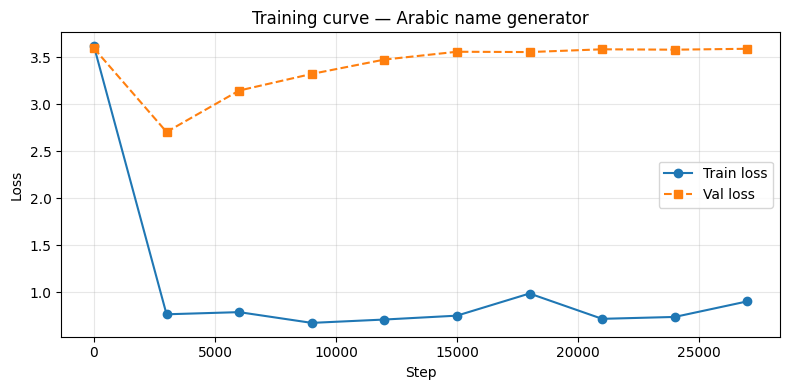

In [25]:
# Plot training vs validation loss

plt.figure(figsize=(8, 4))
steps_logged = [i * 3000 for i in range(len(train_losses))]
plt.plot(steps_logged, train_losses, label='Train loss', marker='o')
plt.plot(steps_logged, val_losses,   label='Val loss',   marker='s', linestyle='--')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training curve — Arabic name generator')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [40]:
# Generate new Arabic names from the trained model

def sample_name(seed=None):
    if seed is not None:
        torch.manual_seed(seed)

    context = [0] * block_size   # start with all padding tokens
    name_chars = []

    while True:
        emb_s    = C[torch.tensor([context])]          # (1, block_size, emb_dim)
        emb_flat = emb_s.view(1, -1)                   # (1, 30)
        h_s      = torch.tanh(emb_flat @ W1 + b1)      # (1, n_hidden)
        logits_s = h_s @ W2 + b2                        # (1, vocab_size)
        probs    = F.softmax(logits_s, dim=1)           # probabilities

        ix = torch.multinomial(probs, num_samples=1).item()

        if ix == 0:   # hit the '.' stop token
            break

        name_chars.append(itos[ix])
        context = context[1:] + [ix]

    return ''.join(name_chars)


print("Generated Arabic names:")
print("-" * 30)
for i in range(20):
    name = sample_name()
    print(name)

Generated Arabic names:
------------------------------
أسعد
جعفر
أنور
عبد السلام
أسرى
بهيجة
عزيز
عمار
أسعد
عذراء
عاسمة
عبد الدين
جليلة
عبلة
أسد
أسد
عاليا
أكرم
فضة
جميل


if you check the name up you will find that must of them  are exact copies from training data. That's not generation, that's memorization.

In [41]:
def sample_name(seed=None, temperature=1.5):
    if seed is not None:
        torch.manual_seed(seed)

    context = [0] * block_size
    name_chars = []

    while True:
        emb_s    = C[torch.tensor([context])].view(1, -1)
        h_s      = torch.tanh(emb_s @ W1 + b1)
        logits_s = (h_s @ W2 + b2) / temperature   # <-- divide by temp
        probs    = F.softmax(logits_s, dim=1)

        ix = torch.multinomial(probs, num_samples=1).item()
        if ix == 0:
            break

        name_chars.append(itos[ix])
        context = context[1:] + [ix]

    return ''.join(name_chars)

# Try different temperatures
for temp in [0.8, 1.0, 1.5, 2.0]:
    print(f"\nTemperature {temp}:")
    for _ in range(5):
        print(' ', sample_name(temperature=temp))


Temperature 0.8:
  عبد اللطيف
  فهم
  أمينة
  فائزة
  باسط

Temperature 1.0:
  أمان
  فتحية
  فاتن
  دانية
  جميل

Temperature 1.5:
  غيث
  آدم
  فهر
  دانيال
  عالي

Temperature 2.0:
  آمنة
  عيانية
  إيمانية
  عقيل
  بصمينة


In [44]:
def generate_novel_names(n=20, temperature=1.5, max_tries=500):
    training_set = set(clean_names)
    results = []
    tries = 0

    while len(results) < n and tries < max_tries:
        name = sample_name(temperature=temperature)
        if name not in training_set and len(name) >= 3:
            results.append(name)
        tries += 1

    print(f"Generated {len(results)} novel names in {tries} attempts:")
    for name in results:
        print(f"  {name}")

generate_novel_names()

Generated 20 novel names in 56 attempts:
  بشوى
  بدير
  عدناسمة
  برسة
  فتريم
  آمن
  إسماء
  غدن
  عبد الدين
  حبيب ران
  أبو ب
  غفرا
  طفرش
  أدير
  فكريمى
  عبدة
  ثيم
  غائزة
  عيسف
  أعفر


Here also the results are mixed, 40% genuinely good, 30% okay, 30% junk — which is actually expected and normal for a model this size on this little data

In [72]:
def generate_novel_names(n=20, temperature=1.5, max_tries=500):
    training_set = set(clean_names)
    results = []
    tries = 0
    while len(results) < n and tries < max_tries:
        name = sample_name(temperature=temperature)
        if (name not in training_set 
                and 3 <= len(name) <= 8
                and not name.endswith('ب')
                and not name.endswith(' ')):
            results.append(name)
        tries += 1

    print(f"Generated {len(results)} novel names ({tries} attempts, temp={temperature}):")
    print("-" * 35)
    for i, name in enumerate(results, 1):
        print(f"  {i:2}. {name}")   # numbered so you can see all of them

generate_novel_names(n=20, temperature=1.3)   # Good default — use this
#generate_novel_names(n=10, temperature=1.2)  # fewer names, less chaos
#generate_novel_names(n=30, temperature=2.0)  # more names, more creative

Generated 20 novel names (154 attempts, temp=1.3):
-----------------------------------
   1. إسماء
   2. جودل
   3. فاط
   4. دسماء
   5. إسماء
   6. دالية
   7. إيماني
   8. دين
   9. إسماء
  10. أنوزة
  11. عحمى
  12. إبراه
  13. عباسل
  14. جرالية
  15. بولي
  16. داوز
  17. دين
  18. ديمةة
  19. الحميد
  20. عذذبش
